# Chapter 50 — The MLP Language Model

## Learning goals

By the end of this chapter, you should be able to:

- Build character-level examples with fixed-length contexts.
- Trace token IDs through embeddings, flattening, hidden values, and next-token logits.
- Build and train a small multilayer perceptron (MLP) language model in PyTorch.
- Generate characters from the trained model.
- Explain why its first linear layer fixes the context length.
- Compare this model with a bigram model and a GPT-style model.

## The big idea

The neural bigram model used one previous token to predict the next token.

An MLP language model can combine several previous tokens in one fixed context window.

For a four-character context, one example is `hell → o`.

The model follows this sequence:

```text
token IDs
→ embedding vectors
→ one flattened context vector
→ linear layer
→ nonlinearity
→ output layer
→ one logit per possible next character
```

## Terms used in this chapter

- A **context window** is the fixed number of previous tokens supplied to the model.
- An **embedding** is a learned floating-point vector selected by a token ID.
- **Flattening** concatenates the embedding at each context position into one longer vector.
- A **linear layer** applies a learned affine transformation.
- A **nonlinearity** such as `Tanh` lets stacked layers represent more than one linear transformation.
- An **MLP** is a feedforward network containing linear layers and nonlinearities.
- A **logit** is a raw class score before softmax.
- **Cross-entropy loss** measures how much probability the model assigns to the correct next-token class.

## Build a small character dataset

Import PyTorch, keep every tensor on the CPU, and create a short repeated training corpus.

The repetition makes the toy patterns learnable and keeps every intermediate value easy to inspect.

In [1]:
import torch

device = "cpu"
RANDOM_SEED = 50

training_text = "hello there. hello cat. hello dog. hello there. hello cat. hello dog. "

print("device:", device)
print("training text:", repr(training_text))
print("number of characters:", len(training_text))

device: cpu
training text: 'hello there. hello cat. hello dog. hello there. hello cat. hello dog. '
number of characters: 70


## Encode characters as token IDs

Assign each unique character a deterministic integer ID by sorting the vocabulary.

The IDs are lookup labels rather than meaningful numerical measurements.

In [2]:
vocabulary = sorted(set(training_text))
vocabulary_size = len(vocabulary)
character_to_id = {character: token_id for token_id, character in enumerate(vocabulary)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}
token_ids = [character_to_id[character] for character in training_text]

print("vocabulary:", vocabulary)
print("vocabulary size:", vocabulary_size)
print("character to ID:", character_to_id)
print("first 40 token IDs:", token_ids[:40])
print(
    "decoded again:", "".join(id_to_character[token_id] for token_id in token_ids[:40])
)

vocabulary: [' ', '.', 'a', 'c', 'd', 'e', 'g', 'h', 'l', 'o', 'r', 't']
vocabulary size: 12
character to ID: {' ': 0, '.': 1, 'a': 2, 'c': 3, 'd': 4, 'e': 5, 'g': 6, 'h': 7, 'l': 8, 'o': 9, 'r': 10, 't': 11}
first 40 token IDs: [7, 5, 8, 8, 9, 0, 11, 7, 5, 10, 5, 1, 0, 7, 5, 8, 8, 9, 0, 3, 2, 11, 1, 0, 7, 5, 8, 8, 9, 0, 4, 9, 6, 1, 0, 7, 5, 8, 8, 9]
decoded again: hello there. hello cat. hello dog. hello


## Create one target for each context

Use the one-target-per-context setup from Chapter 49.

For a context length of four, each input contains four IDs and its target is the immediately following ID.

In [3]:
def build_one_target_context_examples(
    token_ids: list[int],
    context_length: int,
) -> tuple[list[list[int]], list[int]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")

    if len(token_ids) <= context_length:
        raise ValueError("token_ids must be longer than context_length.")

    input_examples: list[list[int]] = []
    target_examples: list[int] = []

    for start_index in range(len(token_ids) - context_length):
        stop_index = start_index + context_length
        input_examples.append(token_ids[start_index:stop_index])
        target_examples.append(token_ids[stop_index])

    return input_examples, target_examples


context_length = 4
input_examples, target_examples = build_one_target_context_examples(
    token_ids=token_ids,
    context_length=context_length,
)

print("number of examples:", len(input_examples))
print("first input IDs:", input_examples[0])
print("first target ID:", target_examples[0])

number of examples: 66
first input IDs: [7, 5, 8, 8]
first target ID: 9


Decode several rows before training to catch window-alignment mistakes.

In [4]:
def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


print("context | target")
print("-" * 24)

for context_ids, target_id in list(zip(input_examples, target_examples, strict=True))[
    :12
]:
    decoded_context = decode_character_ids(context_ids, id_to_character)
    print(f"{decoded_context!r:>9} | {id_to_character[target_id]!r}")

context | target
------------------------
   'hell' | 'o'
   'ello' | ' '
   'llo ' | 't'
   'lo t' | 'h'
   'o th' | 'e'
   ' the' | 'r'
   'ther' | 'e'
   'here' | '.'
   'ere.' | ' '
   're. ' | 'h'
   'e. h' | 'e'
   '. he' | 'l'


The contexts slide by one character, so nearby rows overlap.

The row `'hell' → 'o'` is the concrete example used throughout the chapter.

## Convert the examples to tensors

The input tensor has shape `[number of examples, context length]`.

The target tensor has one correct next-character ID per row, so its shape is `[number of examples]`.

In [5]:
input_token_ids = torch.tensor(
    input_examples,
    dtype=torch.long,
    device=device,
)
target_token_ids = torch.tensor(
    target_examples,
    dtype=torch.long,
    device=device,
)

assert input_token_ids.shape == (len(input_examples), context_length)
assert target_token_ids.shape == (len(target_examples),)

print("input shape:", input_token_ids.shape)
print("target shape:", target_token_ids.shape)
print("input dtype:", input_token_ids.dtype)
print("target dtype:", target_token_ids.dtype)

input shape: torch.Size([66, 4])
target shape: torch.Size([66])
input dtype: torch.int64
target dtype: torch.int64


## Follow the model's shapes

Let `B` be batch size, `C` context length, `D` embedding dimension, `H` hidden size, and `V` vocabulary size.

```text
token IDs:              [B, C]
token embeddings:       [B, C, D]
flattened embeddings:   [B, C × D]
hidden values:          [B, H]
next-token logits:      [B, V]
```

Flattening concatenates the vectors in context-position order.

Position therefore affects which part of the flattened vector reaches the first linear layer.

## See flattening with small numbers

A tiny tensor makes the concatenation visible without involving learned parameters.

In [6]:
fake_embeddings = torch.tensor(
    [
        [
            [1.0, 2.0],
            [3.0, 4.0],
            [5.0, 6.0],
        ]
    ],
    device=device,
)
flattened_fake_embeddings = fake_embeddings.reshape(1, 3 * 2)

print("before flattening:")
print(fake_embeddings)
print("shape:", fake_embeddings.shape)
print()
print("after flattening:")
print(flattened_fake_embeddings)
print("shape:", flattened_fake_embeddings.shape)

before flattening:
tensor([[[1., 2.],
         [3., 4.],
         [5., 6.]]])
shape: torch.Size([1, 3, 2])

after flattening:
tensor([[1., 2., 3., 4., 5., 6.]])
shape: torch.Size([1, 6])


The three position vectors become `[1, 2, 3, 4, 5, 6]`.

Changing the order of the context positions changes the flattened vector.

## Define the MLP language model

The model validates the input rank and context length before applying its layers.

It returns raw logits because PyTorch cross-entropy performs the required normalization internally.

In [7]:
from typing import cast


class MlpLanguageModel(torch.nn.Module):
    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        hidden_size: int,
    ) -> None:
        super().__init__()

        self.context_length = context_length
        self.embedding_dimension = embedding_dimension
        self.token_embedding_table = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.first_linear_layer = torch.nn.Linear(
            context_length * embedding_dimension,
            hidden_size,
        )
        self.nonlinearity = torch.nn.Tanh()
        self.output_layer = torch.nn.Linear(hidden_size, vocabulary_size)

    def forward(self, input_token_ids: torch.Tensor) -> torch.Tensor:
        if input_token_ids.ndim != 2:
            raise ValueError(
                "input_token_ids must have shape [batch size, context length]."
            )

        if input_token_ids.shape[1] != self.context_length:
            raise ValueError(
                f"Expected context length {self.context_length}, "
                f"received {input_token_ids.shape[1]}."
            )

        token_embeddings = self.token_embedding_table(input_token_ids)
        flattened_embeddings = token_embeddings.reshape(
            input_token_ids.shape[0],
            self.context_length * self.embedding_dimension,
        )
        hidden_values = self.first_linear_layer(flattened_embeddings)
        activated_hidden_values = self.nonlinearity(hidden_values)
        return cast(torch.Tensor, self.output_layer(activated_hidden_values))

Create a deterministic model with eight numbers per character embedding and 32 hidden values.

In [8]:
torch.manual_seed(RANDOM_SEED)

embedding_dimension = 8
hidden_size = 32
model = MlpLanguageModel(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=embedding_dimension,
    hidden_size=hidden_size,
).to(device)

print(model)
print("parameter count:", sum(parameter.numel() for parameter in model.parameters()))
print()
for name, parameter in model.named_parameters():
    print(f"{name:35} {tuple(parameter.shape)}")

MlpLanguageModel(
  (token_embedding_table): Embedding(12, 8)
  (first_linear_layer): Linear(in_features=32, out_features=32, bias=True)
  (nonlinearity): Tanh()
  (output_layer): Linear(in_features=32, out_features=12, bias=True)
)
parameter count: 1548

token_embedding_table.weight        (12, 8)
first_linear_layer.weight           (32, 32)
first_linear_layer.bias             (32,)
output_layer.weight                 (12, 32)
output_layer.bias                   (12,)


The embedding table has one row per vocabulary item.

The first linear layer receives `context_length × embedding_dimension = 4 × 8 = 32` features.

The output layer returns one logit per vocabulary item.

## Inspect every major forward-pass shape

Expose intermediate values for three examples without changing the model's normal `forward` interface.

In [9]:
def inspect_mlp_forward_pass(
    model: MlpLanguageModel,
    input_token_ids: torch.Tensor,
) -> dict[str, torch.Tensor]:
    token_embeddings = model.token_embedding_table(input_token_ids)
    flattened_embeddings = token_embeddings.reshape(
        input_token_ids.shape[0],
        model.context_length * model.embedding_dimension,
    )
    hidden_values = model.first_linear_layer(flattened_embeddings)
    activated_hidden_values = model.nonlinearity(hidden_values)
    next_token_logits = model.output_layer(activated_hidden_values)

    return {
        "input token IDs": input_token_ids,
        "token embeddings": token_embeddings,
        "flattened embeddings": flattened_embeddings,
        "hidden values": hidden_values,
        "activated hidden values": activated_hidden_values,
        "next-token logits": next_token_logits,
    }


small_input_batch = input_token_ids[:3]
intermediate_values = inspect_mlp_forward_pass(model, small_input_batch)

for value_name, value in intermediate_values.items():
    print(f"{value_name:27} {tuple(value.shape)}")

assert intermediate_values["input token IDs"].shape == (3, 4)
assert intermediate_values["token embeddings"].shape == (3, 4, 8)
assert intermediate_values["flattened embeddings"].shape == (3, 32)
assert intermediate_values["hidden values"].shape == (3, 32)
assert intermediate_values["next-token logits"].shape == (3, vocabulary_size)

input token IDs             (3, 4)
token embeddings            (3, 4, 8)
flattened embeddings        (3, 32)
hidden values               (3, 32)
activated hidden values     (3, 32)
next-token logits           (3, 12)


The output has one row per context and one column per possible next character.

Decode the same three examples so the tensor rows remain connected to their text.

In [10]:
print("row | context | target")
print("-" * 27)

for row_index in range(small_input_batch.shape[0]):
    decoded_context = decode_character_ids(
        small_input_batch[row_index].tolist(),
        id_to_character,
    )
    target_id = int(target_token_ids[row_index].item())
    decoded_target = id_to_character[target_id]
    print(f"{row_index:>3} | {decoded_context!r:>9} | {decoded_target!r}")

row | context | target
---------------------------
  0 |    'hell' | 'o'
  1 |    'ello' | ' '
  2 |    'llo ' | 't'


## Compute cross-entropy loss

`CrossEntropyLoss` expects raw logits with shape `[B, V]` and integer class targets with shape `[B]`.

Do not apply softmax before passing the logits to this loss.

In [11]:
loss_function = torch.nn.CrossEntropyLoss()
starting_logits = model(input_token_ids)
starting_loss = loss_function(starting_logits, target_token_ids)

print("logit shape:", starting_logits.shape)
print("target shape:", target_token_ids.shape)
print("starting loss:", starting_loss.item())

logit shape: torch.Size([66, 12])
target shape: torch.Size([66])
starting loss: 2.4986789226531982


## Train the model

Use full-batch AdamW for 500 deterministic steps.

This tiny repeated corpus is suitable for demonstrating optimization, but a low training loss here does not establish generalization to new language.

In [12]:
torch.manual_seed(RANDOM_SEED)

model = MlpLanguageModel(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=embedding_dimension,
    hidden_size=hidden_size,
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.03,
    weight_decay=0.0,
)
number_of_steps = 500
training_losses: list[float] = []

for _ in range(number_of_steps):
    next_token_logits = model(input_token_ids)
    loss = loss_function(next_token_logits, target_token_ids)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    training_losses.append(loss.item())

print("initial loss:", training_losses[0])
print("final loss:", training_losses[-1])
print("loss decreased:", training_losses[-1] < training_losses[0])

initial loss: 2.4986789226531982
final loss: 0.09993097931146622
loss decreased: True


Plot the optimization history on a logarithmic vertical scale so both the early and late changes remain visible.

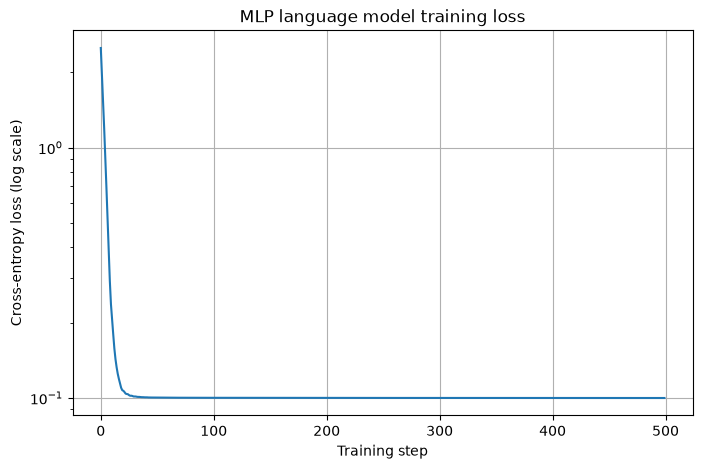

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(number_of_steps), training_losses)
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss (log scale)")
plt.title("MLP language model training loss")
plt.grid(True)
plt.show()

The decline shows that gradient-based updates made the training targets more probable.

Because several identical contexts can have different observed targets, the best possible distribution need not assign probability one to every row.

## Inspect predictions after training

Convert one four-character context to IDs, obtain logits, and apply softmax only for interpretation.

In [14]:
def next_character_probabilities(
    model: MlpLanguageModel,
    context_text: str,
    character_to_id: dict[str, int],
) -> torch.Tensor:
    if len(context_text) != model.context_length:
        raise ValueError(
            f"context_text must contain {model.context_length} characters."
        )

    unknown_characters = [
        character for character in context_text if character not in character_to_id
    ]
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}")

    model_device = next(model.parameters()).device
    context_ids = torch.tensor(
        [character_to_id[character] for character in context_text],
        dtype=torch.long,
        device=model_device,
    ).reshape(1, model.context_length)

    with torch.no_grad():
        logits = model(context_ids)
        return torch.softmax(logits, dim=1).squeeze(0)


context_text = "hell"
probabilities = next_character_probabilities(
    model,
    context_text,
    character_to_id,
)
ranked_token_ids = torch.argsort(probabilities, descending=True)

print("context:", repr(context_text))
print("character | probability")
print("-" * 25)
for token_id in ranked_token_ids.tolist():
    print(f"{id_to_character[token_id]!r:>9} | {probabilities[token_id].item():.6f}")

context: 'hell'
character | probability
-------------------------
      'o' | 0.999984
      '.' | 0.000010
      'a' | 0.000003
      'l' | 0.000002
      'r' | 0.000000
      't' | 0.000000
      'h' | 0.000000
      'g' | 0.000000
      ' ' | 0.000000
      'd' | 0.000000
      'c' | 0.000000
      'e' | 0.000000


The trained model should rank `'o'` highest after `'hell'`, matching the corpus.

Compare several contexts by selecting the highest-probability character.

In [15]:
contexts_to_try = ["hell", "ello", "llo ", "lo c", "lo d", "ther"]

print("context | most likely next character")
print("-" * 38)
for context_text in contexts_to_try:
    probabilities = next_character_probabilities(
        model,
        context_text,
        character_to_id,
    )
    predicted_token_id = int(torch.argmax(probabilities).item())
    print(f"{context_text!r:>9} | {id_to_character[predicted_token_id]!r}")

context | most likely next character
--------------------------------------
   'hell' | 'o'
   'ello' | ' '
   'llo ' | 'c'
   'lo c' | 'a'
   'lo d' | 'o'
   'ther' | 'e'


## Generate text

Generation repeatedly uses the most recent four characters as the next context.

Argmax is deterministic but often repetitive, while seeded sampling can follow less likely branches.

In [16]:
def generate_text(
    model: MlpLanguageModel,
    starting_text: str,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    number_of_new_characters: int,
    sample: bool,
    random_seed: int,
) -> str:
    if len(starting_text) < model.context_length:
        raise ValueError(
            f"starting_text must contain at least {model.context_length} characters."
        )

    torch.manual_seed(random_seed)
    generated_characters = list(starting_text)

    for _ in range(number_of_new_characters):
        context_text = "".join(generated_characters[-model.context_length :])
        probabilities = next_character_probabilities(
            model,
            context_text,
            character_to_id,
        )

        if sample:
            next_token_id = int(torch.multinomial(probabilities, num_samples=1).item())
        else:
            next_token_id = int(torch.argmax(probabilities).item())

        generated_characters.append(id_to_character[next_token_id])

    return "".join(generated_characters)


argmax_text = generate_text(
    model=model,
    starting_text="hell",
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    number_of_new_characters=60,
    sample=False,
    random_seed=RANDOM_SEED,
)
sampled_text = generate_text(
    model=model,
    starting_text="hell",
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    number_of_new_characters=60,
    sample=True,
    random_seed=RANDOM_SEED,
)

print("argmax generation:", repr(argmax_text))
print("sampled generation:", repr(sampled_text))

argmax generation: 'hello cat. hello cat. hello cat. hello cat. hello cat. hello cat'
sampled generation: 'hello there. hello there. hello cat. hello there. hello dog. hel'


Both outputs reflect the small repeated corpus rather than broad language ability.

Every newly generated character becomes available until it slides beyond the four-character window.

## Context length fixes the first layer's size

The first linear layer accepts `context_length × embedding_dimension` input features.

Increasing the context length therefore changes the architecture and increases its parameter count.

In [17]:
def count_first_linear_parameters(
    context_length: int,
    embedding_dimension: int,
    hidden_size: int,
) -> int:
    input_size = context_length * embedding_dimension
    return hidden_size * input_size + hidden_size


print("context | input features | first-layer parameters")
print("-" * 49)
for candidate_context_length in [2, 4, 8, 16, 32]:
    input_size = candidate_context_length * embedding_dimension
    parameter_count = count_first_linear_parameters(
        candidate_context_length,
        embedding_dimension,
        hidden_size,
    )
    print(f"{candidate_context_length:>7} | {input_size:>14} | {parameter_count:>22}")

context | input features | first-layer parameters
-------------------------------------------------
      2 |             16 |                    544
      4 |             32 |                   1056
      8 |             64 |                   2080
     16 |            128 |                   4128
     32 |            256 |                   8224


Doubling the context length doubles the first layer's weight count when the embedding and hidden dimensions stay fixed.

A model built for four positions cannot accept eight positions without replacing and retraining that layer.

## Compare the models

A neural bigram model uses one previous token and directly looks up next-token scores.

This MLP uses several previous tokens, preserves their fixed slots through flattening, and combines them with learned nonlinear computation.

It is still not a GPT because it has no attention, accepts only its configured context length, and produces one prediction for the whole context rather than one prediction at every sequence position.

## Common mistakes

- Do not feed raw integer IDs to a linear layer as meaningful numerical features.
- Use `torch.long` token IDs for embedding lookup.
- Flatten `[B, C, D]` to `[B, C × D]` before this model's first linear layer.
- Pass raw logits rather than softmax probabilities to `CrossEntropyLoss`.
- Supply exactly the context length used to construct the model.
- Treat strong results on this tiny repeated corpus as fitting rather than evidence of general language understanding.

## Takeaways

An MLP language model maps fixed-length token contexts through embeddings, flattening, a hidden nonlinear layer, and an output layer.

Its central shapes are:

```text
[B, C] → [B, C, D] → [B, C × D] → [B, H] → [B, V]
```

The model is more expressive than a bigram table because it combines several previous tokens.

Flattening also hard-codes the number and positions of those tokens into the first linear layer.

## What comes next

This MLP already distinguishes positions because each context slot occupies a fixed part of the flattened vector.

Later sequence models keep token vectors as a sequence instead of flattening them immediately.

The next chapter introduces positional embeddings so those models can represent where each token appears.